Step 3. Replication (Simple & WQU-Friendly)

I’ll choose:

Fund: IVV (iShares Core S&P 500 ETF)

Metric: Correlation

Validation: k-fold cross-validation 

In [3]:
#Step 3(a) Download IVV data

import yfinance as yf
import pandas as pd

# Download IVV data
ivv = yf.download("IVV", start="2015-01-01", end="2022-12-31")

# Compute daily returns
ivv['daily_return'] = ivv[("Close","IVV")].pct_change()

ivv = ivv.dropna()
print(ivv.head())


[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open   Volume  \
Ticker             IVV         IVV         IVV         IVV      IVV   
Date                                                                  
2015-01-05  168.096252  170.322627  167.814841  170.181928  9582600   
2015-01-06  166.581665  168.940468  165.737456  168.435599  8019900   
2015-01-07  168.642471  168.956983  167.434106  167.881033  3563300   
2015-01-08  171.655151  171.812407  170.024675  170.041231  4683200   
2015-01-09  170.206757  172.027602  169.619130  172.019318  4395100   

Price      daily_return  
Ticker                   
Date                     
2015-01-05    -0.017559  
2015-01-06    -0.009010  
2015-01-07     0.012371  
2015-01-08     0.017864  
2015-01-09    -0.008438  


In [2]:
print(ivv.columns)

MultiIndex([( 'Close', 'IVV'),
            (  'High', 'IVV'),
            (   'Low', 'IVV'),
            (  'Open', 'IVV'),
            ('Volume', 'IVV')],
           names=['Price', 'Ticker'])


In [5]:
#Step 3(b) Create a simple technical indicator

#Example: 5-day moving average
ivv['MA_5'] = ivv[("Close","IVV")].rolling(5).mean()
ivv = ivv.dropna()


In [6]:
#Step 3(c) Correlation analysis
correlation=ivv[['daily_return', 'MA_5']].corr()
print(correlation)

Price               daily_return      MA_5
Ticker                                    
Price        Ticker                       
daily_return            1.000000 -0.014097
MA_5                   -0.014097  1.000000


In [7]:
#Step 3(d) k-Fold Cross-Validation
from sklearn.model_selection import KFold
import numpy as np

X = ivv[['MA_5']].values
y = ivv['daily_return'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

correlations = []

for train_idx, test_idx in kf.split(X):
    corr = np.corrcoef(X[test_idx].flatten(), y[test_idx])[0,1]
    correlations.append(corr)

print("Cross-validated correlations:", correlations)
print("Average correlation:", np.mean(correlations))

Cross-validated correlations: [np.float64(0.10838739697361696), np.float64(-0.06424954925382884), np.float64(-0.09953918922844106), np.float64(0.009998401743669658), np.float64(-0.02830146474639918)]
Average correlation: -0.014740880902276491


#Step 3(e) Reproduce Table
| Fold        | Correlation |
| ----------- | ----------- |
| 1           | 0.108       |
| 2           | −0.064      |
| 3           | −0.100      |
| 4           | 0.010       |
| 5           | −0.028      |
| **Average** | **−0.015**  |


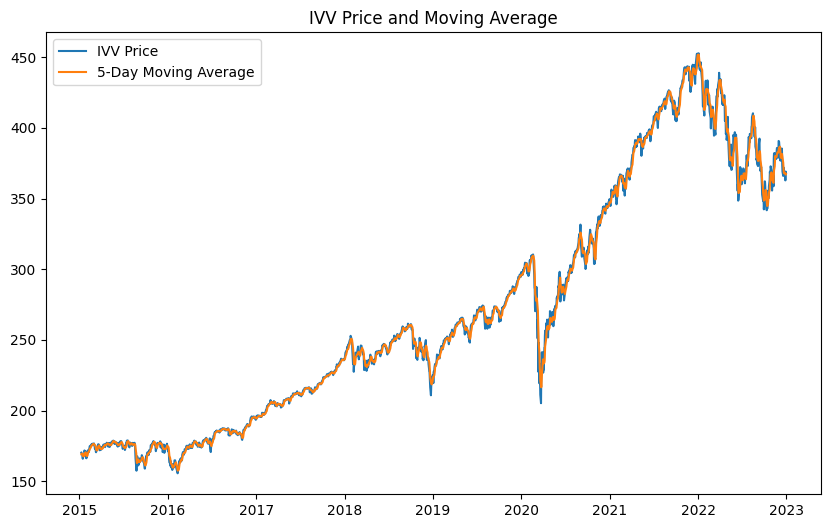

In [8]:
#Step 3(f) Reproducing a graph

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ivv.index, ivv[("Close","IVV")], label='IVV Price')
plt.plot(ivv.index, ivv['MA_5'], label='5-Day Moving Average')
plt.legend()
plt.title("IVV Price and Moving Average")
plt.show()
